# APAAD2026M0704 - Desafio: Sistema de Detecção de Fraudes

## 1. Cenário Inicial: Detecção de Fraudes em Sistemas Bancários

###  1.1 Coleta de dados
- Utilização do dataset _creditcard.csv_.
- Se trata de um dataset bastante utilizado para treino de modelos que buscam identificar transações fraudulentas.
- Os dados utilizados possuem características históricas que podem ajudar o modelo a detectar aspectos incomuns dentro de uma transação.


In [1]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

### 1.2 Reconhecimento do dataset

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


- Cada linha se trata de uma operação feita com cartão de crédito.
- `time` repreenta o tempo utilizado para concluir a transação.
- `V's` são variáveis transformadas (por se tratarem de dados sensíveis) po técnicas de `PCA`.
- `amount` é o valor da transação.
- `classe` indica se a transação é fraudulenta ou não.

### 1.3 Análise de desbalanceamento
- Verifica se uma classe aparece majoritáriamente mais que outras.

In [3]:
proporcao_class = df["Class"].value_counts(normalize=True) # Calcula a proporção entre as classes existentes
proporcao_class

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

- No contexto, a proporção revela uma quantidade extremamente pequena das fraudes que ocorreram.
- Por esse motivo, o modelo pode ignorar as causas de uma fraude pela proporção de pouca fraude.
- A métrica `recall` ajuda a verificar quantas fraudes o modelo conseguiu identificar dentre todas as fraudes reais.
- Precision diz se uma fraude identificada é realmente uma fraude.

### 1.4 Transormação dos dados com Feature Engineering
- Consiste em criar váriaveis que possam ajudar o modelo e seu aprendizado em caso de desbalanceamento do dos dados.
- Essas variáveis podem ser as variáveis do dataset também, mas podem não ser suficientes.
- Permite transformar dados brutos em informações úteis pro modelo.
- O modelo entende apenas padrões matemáticos.

- O código abaixo cria uma variável que transforma os valores da coluna amount, comprimindo a escala de muitos valores e melhorando a distribuição dos dados.

In [4]:
import numpy as np 

df["Amount_log"] = np.log1p(df["Amount"]) 


- O código abaixo faz as seguintes transformações:
    - Transforma os dados para que tenha média igual a 0 e desvio padrão igual a 1.
    - Os valores ficam na mesma escala independente do tamanho original.
    - Valores grandes e pequenos passam a ser comparáveis em uma escala comum.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]]) # Calcula a média e o desvio padrão

### 1.5 Treinamento do modelo

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1) # Anexação do dataframe com as features + variáveis-explicativas e sem a presença da variável-resposta "Class"
y = df["Class"] # Variável-resposta, usada na comparação após o modelo prever as classificações.

X_train, X_test, y_train, y_test = train_test_split( # Separa os dados em conjuntos de treino teste (X = treino, y = avaliação)
    X, y,
    stratify = y, # Garante que a proporção de fraudes e nãi-fraudes seja mantida
    test_size = 0.3, # 30% dos dados pra teste, 70% pra treino
    random_state = 42 # Garante uma divisão consistente dos dados
)

## 2. Avaliação e Técnicas de Avaliação

### 2.1 Regressão Logística
- O modelo que será utilizado para a avaliação das fraudes entra no escopo de classificação.
- Logo, utilizaremos o modelo de **Regressão Logística**.
- Utilizada para prever classes.

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000) # Iterações de convergência dos dados para aprendizado

model.fit(X_train, y_train) # Aprende padrões pelos dados de treino sem a variável-resposta

y_pred = model.predict(X_test) # Tenta prever os classes com base no conjunto de avaliação


c:\Users\Estudo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


_Obtendo as métricas:_

In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.68      0.74       148

    accuracy                           1.00     85443
   macro avg       0.91      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



- Observando a classe 1, que representa as fraudes:
    - Precision: 83% entre todas as transações foram classificadas como fraudes.
    - **Recall**: 68% das fraudes reais foram identificadas.
    - F1: Equilibrio de 74% entre Precision e Recall.
- Accuracy deu 100%, mas pelas outras métricas, há uma contraposição a esse resultado.
    - Ocorre pelo desbalanceamento dos dados, que há 99% de transações dadas como normais.


### 2.2 Curva ROC
- Demonstra o desempenho da previsão do modelo em diferentes limiares de decisão.
- Eixo horizontal:
    - Taxa de falsos positivos.
    - Transações normais foram identificadas como fraudes
- Eixo vertical:
    - Taxa de fraudes reais identificadas em relação as que são realmente fraudes.
    - Semelhante ao _Recall_.
- Pontos da curva:
    - Limite de decisão do modelo.
    - É analisada como um todo.
    - Quanto mais a curva se aproxima do canto superior esquerdo = consistência do modelo.
    - Linha reta diagonal = aleatoriedade.
- AUC:
    - Mostra a proporção geral da medida.
    - Mais próximo de 1 = consistência.

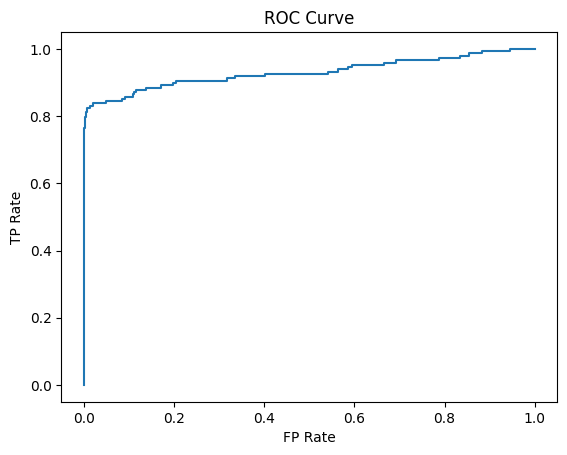

AUC:  0.9300096802353676


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FP Rate")
plt.ylabel("TP Rate")
plt.show()

print("AUC: ", roc_auc_score(y_test, y_probs))

### 2.3 Precision Recall Curve
- Mostra um comportamento do modelo mais fiel que a _ROC Curve_.
- Gráfico que mostra o equilíbrio entre _Precision_ e _Recall_.
- Interpretações básicas:
    - Quando o _Recall_ aumenta, a precisão cai, pois os falsos positivos tendem a aparecer frequentemente.
    - Quando o Recall está alto e o Precision baixo, representa muitas classiicações de fraude, mesmo as que não são.


### 2.4 Balanceamento de dados com _undersampling_
- Consiste em reduzir a classe majoritária na mesma proporção da classe minoritária.
- Utilizado para melhorar o aprendizado do modelo na ausência de muitas evidências da classe a ser identificada (fraudes, 1).
- Problema: dados normais (0) podem se perder, afetando na identificação de não-fraudes.

In [10]:
fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state = 42)

df_under = pd.concat([fraudes, normais])

print(df_under["Class"].value_counts(normalize=True))

Class
1    0.5
0    0.5
Name: proportion, dtype: float64


### 2.5 Balanceamento de dados com _oversampling_
- Consiste em criar sintéticamente dados da classe minoritária para balancear as proporções.
- Trade-offs:
    - Não perde dados das classes majoritárias.
    - Como cria dados de forma artificial, gera ruídos no aprendizado.

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X, y)

## 3. Modelos avançados e explicabilidade

### 3.1 Random Forest
- Modelo com uma sofisticação maior.
- Conjunto de árvores de decisão que aprendem padrões dos dados e combinam para tomar decisões.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 50, # 50 árvores
    max_depth = 10, # Limite da profundidade das arvores para evitar overfitting
    class_weight = "balanced", # Peso das classes, equlibrando as ocorrências
    n_jobs = -1,
    random_state = 42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



### 3.2 Pipeline
- Organiza o fluxo de processamento do modelo.

### 3.3 Threshold
- Gatilho que dispara caso a proporção de uma ocorrência identificada atenda as condições

In [15]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([ # Organiza o fluxo
    ("scaler", StandardScaler()), # Padroniza os dados
    ("model", LogisticRegression(max_iter=1000)) # Entra no modelo
])

pipeline.fit(X_train, y_train) # Treino do modelo

y_pred = pipeline.predict(X_test) # Predição

threshold = 0.3 # Gatilho de probabilidade

y_pred_custom = (y_probs > threshold) # Ocorrências com probabilidade > 0.3 são consideradas fraudes

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.78      0.71      0.74       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



### 3.4 XGBoost
- Algoritmo de classificação avançado baseado em _boosting_
- _Boosting_:
    - Modelos com árvores treinadas em sequência.
    - Cada árvore tenta corrigir a imprecisão da árvore anterior.

In [16]:
from xgboost import  XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight = 10,
    use_label_encoder = False,
    eval_metric = "logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



### 3.5 Importância das variáveis
- Fator que mostra qual o peso de cada variável na tomada de decisão de cada modelo com suas previsões.
- Ajuda a dar um embasamento e confiabilidade maior para os resultados obtidos.
- No contexto, a variável mais destacada nas barras indica um padrão recorrente que demonstre uma transação fraldulenta.
- Ajuda na seleção das variáveis no sentido de que:
    - Variáveis com menos impacto na decisão podem ser removidas do dataframe a ser analisado pelo modelo.
    - Entendimento do negócio, uma vez que a quantidade de informações podem ser reduzidas, dando mais clareza para compreender a relação dos padrões das variáveis com fraudes.

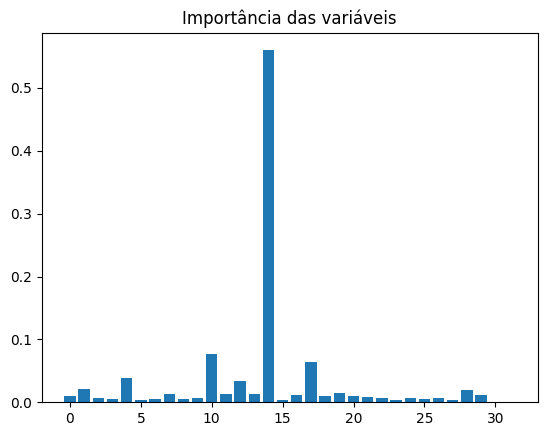

In [17]:
importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()


### 3.6 Ajustes de hiperparâmetros
- Fator que consiste no teste de combinações variadas de parâmetros para identificar quais se ajustam melhor a cada modelo utilizado.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = { # Conjunto de combinações para teste
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV( # Testa todas as combinações possíveis de parâmetros em vários modelos
    XGBClassifier(eval_metrics = "logloss"),
    param_grid,
    scoring = "recall",
    cv = 3
)

grid.fit(X_train, y_train)

print(f"Parametrização adequada para XGBoosting: {grid.best_params_}")

Parametrização adequada para XGBoosting: {'max_depth': 3, 'n_estimators': 100}


### 3.7 Explicabilidade (SHAP)
- Explica como cada variável contribui para decisão do modelo.
- Mostra o impacto médio de cada variável na decisão tomada pelo modelo.
- Interpretação básica:
    - Quanto maior o valor, maior vai ser o impacto da variável na decisão.
- Importância na confiabilidade e para auditoria do processo de decisão do modelo.

c:\Users\Estudo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


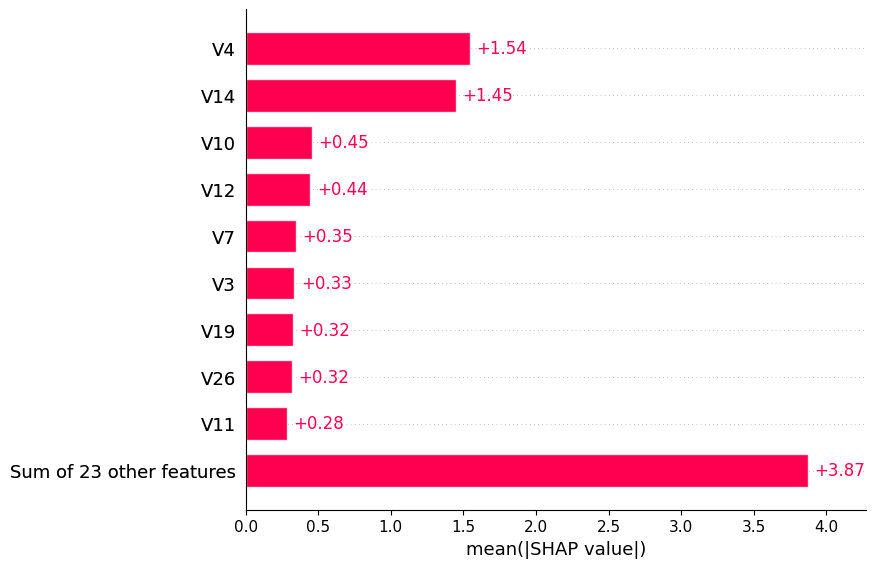

In [23]:
import shap

explainer = shap.Explainer(xgb)

shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)